## Normen und Matrixnormen
Die am häufigsten verwendeten **Vektornormen** sind die $1$, $2$, und $\inf$ Norm, wobei

\begin{eqnarray*}
    |\vec{x}|_{1} &=& \sum_{i=1}^{n} |x_i| \\
    |\vec{x}|_{2} &=& \sqrt{\sum_{i=1}^{n} |x_i|^2 } \\
    |\vec{x}|_{\inf} &=& \max |x_i|
\end{eqnarray*}

Die Einheitskreise in $\mathbb{R}^2$, d.h. die Mengen, $\{|x| = 1 \}$ in den drei Normen sehen dann so aus

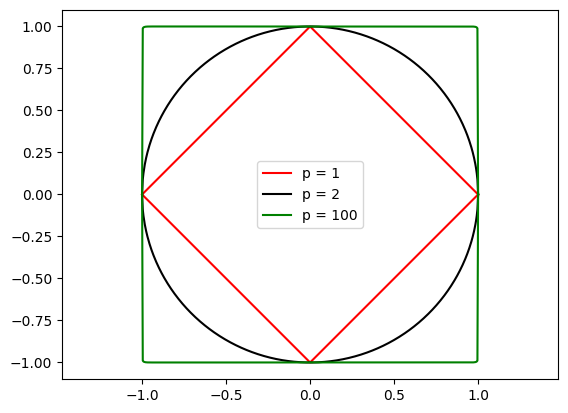

In [9]:
# -*- coding: utf-8 -*-
"""
Created on Wed Feb  4 22:28:11 2026

@author: jaeg
"""

import numpy as np
import matplotlib.pyplot as plt 

ps = [1, 2, 100]
cs = ["r", "k", "g","b"]
ls = ["-","-","-","-","-"]

vd = {ps[0]:v[:,0], ps[1]:v[:,1],ps[2]:v[:,2] }
# %%
x = np.linspace(-1, 1, 500)
for p, col in zip(ps, cs):
    y = (1 - np.abs(x)**p)**(1/p)
    
    # "Einheitskreis"  und Bild davon 
    plt.plot(x,  y, color = col, label = f"p = {p}")
    plt.plot(x, -y, color = col )
    
plt.axis("equal")
plt.legend()



### Matrixnormen
Die Norm einer Matrix $A$ bezogen auf die jeweilige Vektornorm ist dann

$$
    ||A|| = \max\{ |A x| : |x| = 1 \}
$$

in Worten: $||A||$ ist der maximale **Streckungsfaktor** eines Vektors $A x$ unter der Matrix $A$. In $\mathbb{R}^2$ kann man die Bilder des jeweiligen Einheitskreises unter der Matrix $A$ und den zugehörigen Vektor zeichnen.
    

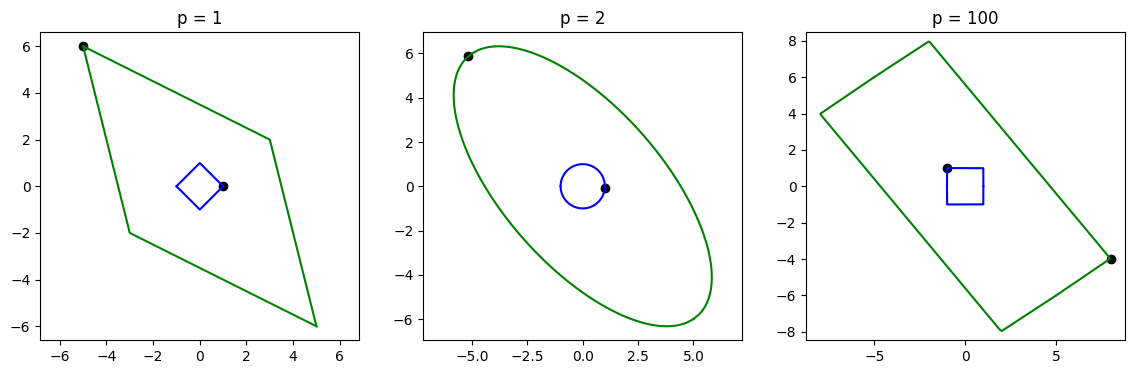

In [12]:
# -*- coding: utf-8 -*-
"""
Created on Wed Feb  4 22:28:11 2026

@author: jaeg
"""

import numpy as np
import matplotlib.pyplot as plt 

ps = [1, 2, 100]
cs = ["r", "k", "g","b"]
ls = ["-","-","-","-","-"]

# %%
# "vernünftig"
A = np.array([[1, 2], [-1, 3]])
A = np.array([[-5, 3], [6, 2]])
# A = np.random.randn(2, 2)


# schlecht konditioniert
# A = np.array([[1, 2], [-2, -4.001]])
# A = np.linalg.inv(A)


"""
# Orthogonal ("Drehung / Spiegelung", |A| = 1)
A = np.array([[1, 2], [-2, 1]]) / np.sqrt(5)
"""
v = np.zeros( (2, 3) )
# %% jeweils den Vektor mit dem maximalen Streckungsfaktor bestimmen
# 1- Norm
s = np.sum(np.abs(A), axis = 0)
nrm1 = np.max(s)
v[np.argmax(s), 0] = 1

# 2 - Norm
val, vec = np.linalg.eig(A.T@A)
val = np.sqrt(val)
v[:,1] = vec[:,np.argmax(val)]

# inf- Norm
s = np.sum(np.abs(A), axis = 1)
nrm1 = np.max(s)
i = np.argmax(s)
v[:,2] = np.sign(A[i,:])

vd = {ps[0]:v[:,0], ps[1]:v[:,1],ps[2]:v[:,2] }
# %%
fig, axes = plt.subplots(1, 3, figsize = (14, 4) )
x = np.linspace(-1, 1, 500)
for p, col, ax in zip(ps, cs, axes):
    y = (1 - np.abs(x)**p)**(1/p)
    
    # "Einheitskreis"  und Bild davon 
    ax.plot(x,  y, color = "b", label = f"p = {p}")
    ax.plot(x, -y, color = "b", )
    ax.plot( (A@[x,y])[0],(A@[x,y])[1], color = "g" )
    ax.plot( (A@[x,-y])[0],(A@[x,-y])[1], color = "g" )
    
    ax.scatter(*vd[p], color = "k")
    ax.scatter(*(A@vd[p]), color = "k")
    
    ax.axis("equal")
    ax.set_title(f"p = {p}")


## Konditionszahlen von Matrizen
In der linearen Algebra ist eine Matrix $A \in \mathbb{R}^{n \times n}$ entweder **regulär**, d.h. die Zeilen (und Spalten) sind linear unabhängig oder **singulär**, d.h. die Spalten sind linear abhängig. Im ersten Fall hat jedes lineare Gleichungssystem 

$$
    A \vec{x} = \vec{b}
$$

eine eindeutig bestimmte Lösung, im zweiten Fall nicht. In der Numerik ist der Übergang etwas fliessend: eine Matrix, die "nahe an einer singulären Matrix liegt" hat eine grosse **Konditionszahl**. Beispiele 
$$
    A = \begin{pmatrix} 1 & 2 \\ 3 & 4 \end{pmatrix}, \quad
    B = \begin{pmatrix} 1 & 2 \\ 2.01 & 4 \end{pmatrix}, \quad
    C = \begin{pmatrix} 1 & 2 \\ 2 & 4 \end{pmatrix}
$$

Hier ist die Matrix $A$ regulär, $C$ ist singulär und $B$ ist zwar regulär aber nicht so gut konditioniert. Typisch für schlecht konditionierte Matrizen ist, dass die Koeffizienten in $A^{-1}$ deutlich grösser sind, als in $A$.

In [16]:
import numpy as np

B = np.array([[1, 2],[2.01, 4]])

print("B = \n", B, "\n")
print("inv(B) = \n", np.linalg.inv(B))

B = 
 [[1.   2.  ]
 [2.01 4.  ]] 

inv(B) = 
 [[-200.   100. ]
 [ 100.5  -50. ]]


"Nicht so gut konditioniert" heisst: die Matrix ist "nahe bei" einer singulären Matrix. Wegen

$$
    A (\vec{x} + \vec{\Delta}_x) = \vec{b} + {\color{red} \vec{\Delta}_b  } 
$$

schlägt ein Fehler $\vec{\Delta}_b$ in der Form 

$$
\vec{\Delta}_x = A^{-1} \vec{\Delta}_b
$$

auf das Ergebnix $\vec{x}$ durch. Die **absolute Konditionszahl** einer Matrix ist demnach einfach

$$
    \kappa_{abs} = |A^{-1}|
$$

und durch Umformungen lässt sich daraus die **relative Konditionszahl**

$$
    \kappa_{rel} = |A| \cdot |A^{-1}|
$$

gewinnen. Deren Bedeutung ist bekanntlich

$$
    \frac{|\vec{\Delta}_x|}{|\vec{x}|} \leq \kappa_{rel} \cdot \frac{|\vec{\Delta}_b|}{|\vec{b}|}
$$

Die Konditionszahl lässt sich in numpy mit dem Befehl _cond_ berechnen. Gemeint ist dabei immer die *relative* Konditionszahl. Welche Vektornorm verwendet wird, spielt für die Grössenordnung keine Rolle.

In [18]:
for nrm in (1, 2, np.inf):
    print("Konditionszahl bezüglich der ", nrm, " - Norm ", np.linalg.cond(B, nrm))

Konditionszahl bezüglich der  1  - Norm  1803.0000000000484
Konditionszahl bezüglich der  2  - Norm  1252.0042012805109
Konditionszahl bezüglich der  inf  - Norm  1803.0000000000484


Nicht *jeder* Fehler im Eingang wird mit $\kappa$ multipliziert im Ausgang erscheinen. Der "worst case" tritt ein, wenn

$$
    |B \vec{x}| = |B| \cdot |\vec{x}| \quad \textrm{und} \quad  |B^{-1} \vec{\Delta}_b| = |B^{-1}| \cdot |\vec{\Delta}_b|
$$

Für die obige Matrix $B$ wäre ein solches Beispiel bezogen auf die $\infty$-Norm

$$
    \vec{x} = (1, 1), \quad \vec{\Delta}_b = (1, -1)
$$

Worst cases bezogen auf andere Normen könnten in ähnlicher Weise konstruiert werden.


In [19]:
def printErr(A, x, db):

    b = A @ x
    dx = np.linalg.solve(A, db)
    
    print("b = ", b,      "\t ==> \t x = ", x)
    print("b = ", b + db, "\t ==> \t x = ", x + dx)
    
    errOut = np.linalg.norm(dx, np.inf) / np.linalg.norm(x, np.inf)
    errIn  = np.linalg.norm(db, np.inf) / np.linalg.norm(b, np.inf)
    
    print("Fehler im Eingang b: ", 100 * errIn, "%")
    print("Fehler im Ausgang x: ", 100 * errOut, "%")
    
    print("Verstärkung des Fehlers um Faktor ", errOut / errIn)
    
x  = np.array([1, 1])
db = np.array([1, -1]) * 1e-2

printErr(A, x, db)



b =  [3.   6.01] 	 ==> 	 x =  [1 1]
b =  [3.01 6.  ] 	 ==> 	 x =  [-2.     2.505]
Fehler im Eingang b:  0.16638935108153077 %
Fehler im Ausgang x:  300.0000000000081 %
Verstärkung des Fehlers um Faktor  1803.0000000000484


Für "zufällige" x und db kann die Verstärkung auch kleiner sein:

In [20]:
x  = np.random.randn( 2 )
db = np.random.randn( 2 ) * 1e-2

printErr(A, x, db)

b =  [-1.70643728 -3.41466559] 	 ==> 	 x =  [-0.17910431 -0.76366648]
b =  [-1.68555856 -3.41640176] 	 ==> 	 x =  [-4.52846455  1.421453  ]
Fehler im Eingang b:  0.6114425149902394 %
Fehler im Ausgang x:  569.5366156240391 %
Verstärkung des Fehlers um Faktor  931.4638770794844


## Interpolation von Punkten

Als Beispiel einer Aufgabe, die notorisch auf schlecht konditionierte Matrizen führt, betrachten wir die **Interpolation von Punkten durch ein Polynom**. 

Gegebene Punkte 
$$
    (x_i, y_i), \qquad (i = 0, \ldots, N)
$$ 

sollen durch ein Polynom 

$$
    p(x) = p_0 + p_1 \cdot x + \ldots + p_{N} \cdot x^N 
$$

interpoliert werden. Die Aufgabe ist eindeutig lösbar, solange $x_i \neq x_j$, aber numerisch sehr ungünstig, sobald $N$ "gross" ist, z.B. $N > 5$. 

Wir haben zur Bestimmung der Koeffizienten das $(N + 1) \times (N + 1)$ LGS

$$
    p(x_i) = y_i , \qquad (i = 0, \ldots, N)
$$

zu lösen.

$$
    \begin{pmatrix}
        1      & x_0  & x_0^2 & x_0^3 & \ldots & x_0^N \\ 
        1      & x_1  & x_1^2 & x_1^3 & \ldots & x_1^N \\
        \vdots &      &       &       &        & \vdots \\
        1      & x_N  & x_N^2 & x_N^3 & \ldots & x_N^N \\
    \end{pmatrix} \cdot {\color{blue} \begin{pmatrix} p_0 \\ p_1 \\ \vdots \\ p_N \end{pmatrix}} = \begin{pmatrix} y_0 \\ y_1 \\ \vdots \\ y_N \end{pmatrix}
$$


Konditionszahl von A:  4687375233.0


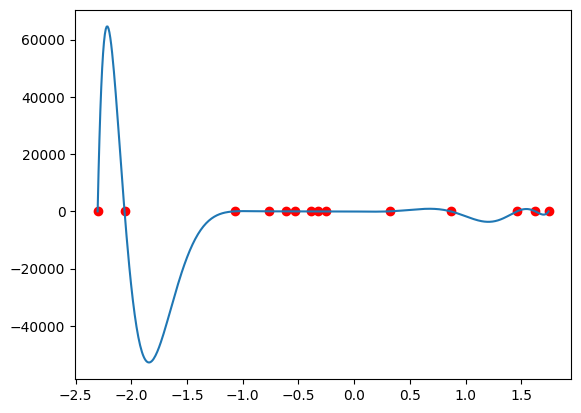

In [21]:
import matplotlib.pyplot as plt 

np.random.seed(1) # ergibt eine feste Folge von "Zufallszahlen"

N = 13
x = np.random.randn(N+1) # N+1 Punkte x_0 ... x_N
y = np.random.randn(N+1) # N+1 Punkte x_0 ... x_N

e = np.arange(N+1)
A = np.array([x[k]**e for k in range(N+1)])

print("Konditionszahl von A: ", np.round(np.linalg.cond(A)))

p = np.flip( np.linalg.solve(A, y) )        # Koeffizienten p aus linsolve. flip für polyval
xx = np.linspace(np.min(x), np.max(x), 500)
yy = np.polyval(p, xx)

plt.scatter(x, y, color = "red")
plt.plot(xx, yy)
# plt.ylim([-1, 1])

Wir verschieben die Punkte ein bisschen

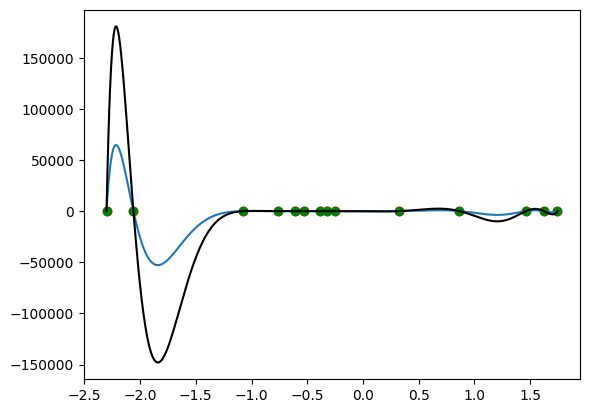

In [22]:
# Polynom und Punkte von oben nochmal zeichnen
plt.scatter(x, y, color = "red")
plt.plot(xx, yy)

y[2]+= 3 # einen Punkt etwas verschieben (in y)
# x[1] -= 0.03 # ... oder in x

A = np.array([x[k]**e for k in range(N+1)])

p2 = np.flip( np.linalg.solve(A, y) )
xx = np.linspace(np.min(x), np.max(x), 500)
yy = np.polyval(p2, xx)

plt.scatter(x, y, color = "green")
plt.plot(xx, yy, color = "k")

Die Lösung des Problems besteht im übrigen darin, an Stelle *eines* globalen Polynoms stückweise Polynome, aka **Splines** zu verwenden.